# GRU Model Development for Binary Classification

## Import Python's Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

## Loading and Reshaping Data

In [2]:
data = np.load("../../../data/ukb_processed/train/ternary_classification_datas.npy")          # load datas
label = np.load("../../../data/ukb_processed/train/ternary_classification_labels.npy")   # load labels

x = data.reshape(data.shape[0], data.shape[1], 1)
y = label

print(f"Binary Classification Dataset: {x.shape}, Labels: {np.unique(y)}")

Binary Classification Dataset: (540, 4097, 1), Labels: [0 1 2]


## Train Data using GRU

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score, 
                           accuracy_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import json

# Create directories for results
os.makedirs('cv_results', exist_ok=True)
os.makedirs('cv_results/training_logs', exist_ok=True)

# Initialize
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_results = []
confusion_matrices = []
all_histories = []
all_roc_data = []
class_names = ['Class_0', 'Class_1', 'Class_2']

# Initialize lists for detailed training logs
training_logs = []
epoch_by_epoch_data = []

print("Starting 10-Fold Cross Validation for Ternary Classification...")
print("=" * 60)

for fold_no, (train_index, val_index) in enumerate(skf.split(x, y), 1):
    print(f"\n🔄 Processing Fold {fold_no}/10")
    
    # Split data
    X_train_fold, X_val_fold = x[train_index], x[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]
    
    # Convert to categorical (one-hot encoding for 3 classes)
    y_train_categorical = to_categorical(y_train_fold, num_classes=3)
    y_val_categorical = to_categorical(y_val_fold, num_classes=3)
    
    # Custom callback
    class myCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs={}):
            if((logs.get('val_accuracy') > 0.95) and (logs.get('accuracy') > 0.95)):
                print(f"\n✅ Target reached at epoch {epoch + 1}")
                self.model.stop_training = True
    
    # Build model - Same architecture, output for ternary classification
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=(x.shape[1], 1)),
        Dropout(0.2),
        GRU(64),
        Dropout(0.2),
        Dense(3, activation='softmax')  # Ternary classification: 3 neurons with softmax
    ])
    
    # Categorical crossentropy for multi-class classification
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # Train model
    start_time = time.time()
    history = model.fit(X_train_fold, y_train_categorical, 
                        epochs=20, batch_size=30, 
                        validation_data=(X_val_fold, y_val_categorical),
                        callbacks=[myCallback()], verbose=1)
    
    training_time = time.time() - start_time
    
    # Evaluate
    scores = model.evaluate(X_val_fold, y_val_categorical, verbose=0)
    val_loss, val_accuracy = scores
    
    # Predictions
    y_pred_proba = model.predict(X_val_fold, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Calculate metrics for multi-class
    precision_macro = precision_score(y_val_fold, y_pred, average='macro')
    recall_macro = recall_score(y_val_fold, y_pred, average='macro')
    f1_macro = f1_score(y_val_fold, y_pred, average='macro')
    
    precision_weighted = precision_score(y_val_fold, y_pred, average='weighted')
    recall_weighted = recall_score(y_val_fold, y_pred, average='weighted')
    f1_weighted = f1_score(y_val_fold, y_pred, average='weighted')
    
    # Per-class metrics
    precision_per_class = precision_score(y_val_fold, y_pred, average=None)
    recall_per_class = recall_score(y_val_fold, y_pred, average=None)
    f1_per_class = f1_score(y_val_fold, y_pred, average=None)
    
    # AUC for multi-class (One-vs-Rest)
    try:
        auc_macro = roc_auc_score(y_val_categorical, y_pred_proba, average='macro', multi_class='ovr')
        auc_weighted = roc_auc_score(y_val_categorical, y_pred_proba, average='weighted', multi_class='ovr')
        # Per-class AUC
        auc_per_class = roc_auc_score(y_val_categorical, y_pred_proba, average=None, multi_class='ovr')
    except:
        auc_macro = 0.0
        auc_weighted = 0.0
        auc_per_class = [0.0, 0.0, 0.0]
    
    # Confusion Matrix
    cm = confusion_matrix(y_val_fold, y_pred)
    
    # Class distribution in validation set
    class_counts = np.bincount(y_val_fold, minlength=3)
    
    # Store results
    fold_result = {
        'Fold': fold_no,
        'Val_Accuracy': val_accuracy,
        'Val_Loss': val_loss,
        
        # Macro averages
        'Precision_Macro': precision_macro,
        'Recall_Macro': recall_macro,
        'F1_Score_Macro': f1_macro,
        'AUC_Macro': auc_macro,
        
        # Weighted averages
        'Precision_Weighted': precision_weighted,
        'Recall_Weighted': recall_weighted,
        'F1_Score_Weighted': f1_weighted,
        'AUC_Weighted': auc_weighted,
        
        # Per-class metrics
        'Precision_Class_0': precision_per_class[0],
        'Precision_Class_1': precision_per_class[1],
        'Precision_Class_2': precision_per_class[2],
        'Recall_Class_0': recall_per_class[0],
        'Recall_Class_1': recall_per_class[1],
        'Recall_Class_2': recall_per_class[2],
        'F1_Class_0': f1_per_class[0],
        'F1_Class_1': f1_per_class[1],
        'F1_Class_2': f1_per_class[2],
        'AUC_Class_0': auc_per_class[0],
        'AUC_Class_1': auc_per_class[1],
        'AUC_Class_2': auc_per_class[2],
        
        # Class distribution
        'Class_0_Count': class_counts[0],
        'Class_1_Count': class_counts[1],
        'Class_2_Count': class_counts[2],
        
        'Training_Time': training_time,
        'Epochs_Trained': len(history.history['loss'])
    }
    
    fold_results.append(fold_result)
    confusion_matrices.append(cm)
    all_histories.append(history.history)
    
    # Store ROC data for each class
    roc_fold_data = {}
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_val_categorical[:, i], y_pred_proba[:, i])
        roc_fold_data[f'class_{i}'] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_per_class[i]}
    all_roc_data.append(roc_fold_data)
    
    # Save model for this fold
    model_filename = f'cv_results/models/lstm_ternary_fold_{fold_no}.h5'
    model.save(model_filename)
    print(f"   💾 Model saved: {model_filename}")
    
    # ==================== LOG TRAINING HISTORY ====================
    # Log detailed training history for this fold
    fold_training_log = {
        'fold': fold_no,
        'epochs_completed': len(history.history['loss']),
        'final_train_loss': history.history['loss'][-1],
        'final_train_accuracy': history.history['accuracy'][-1], 
        'final_val_loss': history.history['val_loss'][-1],
        'final_val_accuracy': history.history['val_accuracy'][-1],
        'best_val_accuracy': max(history.history['val_accuracy']),
        'best_val_accuracy_epoch': np.argmax(history.history['val_accuracy']) + 1,
        'min_val_loss': min(history.history['val_loss']),
        'min_val_loss_epoch': np.argmin(history.history['val_loss']) + 1,
        'overfitting_gap': history.history['accuracy'][-1] - history.history['val_accuracy'][-1],
        'early_stopped': len(history.history['loss']) < 20,
        'training_time': training_time,
        'classification_type': 'ternary',
        'num_classes': 3,
        'class_0_count': class_counts[0],
        'class_1_count': class_counts[1], 
        'class_2_count': class_counts[2],
        'convergence_speed': np.argmax(history.history['val_accuracy']) + 1,
        'precision_class_0': precision_per_class[0],
        'precision_class_1': precision_per_class[1],
        'precision_class_2': precision_per_class[2],
        'recall_class_0': recall_per_class[0],
        'recall_class_1': recall_per_class[1],
        'recall_class_2': recall_per_class[2],
        'f1_class_0': f1_per_class[0],
        'f1_class_1': f1_per_class[1],
        'f1_class_2': f1_per_class[2],
        'auc_class_0': auc_per_class[0],
        'auc_class_1': auc_per_class[1],
        'auc_class_2': auc_per_class[2]
    }
    training_logs.append(fold_training_log)
    
    # Save individual fold detailed history to CSV
    fold_history_data = []
    for epoch_idx in range(len(history.history['loss'])):
        epoch_record = {
            'fold': fold_no,
            'epoch': epoch_idx + 1,
            'train_loss': history.history['loss'][epoch_idx],
            'train_accuracy': history.history['accuracy'][epoch_idx],
            'val_loss': history.history['val_loss'][epoch_idx],
            'val_accuracy': history.history['val_accuracy'][epoch_idx],
            'classification_type': 'ternary',
            'num_classes': 3,
            'learning_rate': 0.001
        }
        fold_history_data.append(epoch_record)
    
    # Save individual fold history
    fold_history_df = pd.DataFrame(fold_history_data)
    fold_history_filename = f'cv_results/training_logs/fold_{fold_no}_detailed_history.csv'
    fold_history_df.to_csv(fold_history_filename, index=False)
    
    # Create epoch-by-epoch data for this fold (for aggregated file)
    for epoch_idx in range(len(history.history['loss'])):
        epoch_data = {
            'fold': fold_no,
            'epoch': epoch_idx + 1,
            'train_loss': history.history['loss'][epoch_idx],
            'train_accuracy': history.history['accuracy'][epoch_idx],
            'val_loss': history.history['val_loss'][epoch_idx],
            'val_accuracy': history.history['val_accuracy'][epoch_idx],
            'learning_rate': 0.001,  # Adam default
            'classification_type': 'ternary',
            'num_classes': 3
        }
        epoch_by_epoch_data.append(epoch_data)
    
    print(f"   📝 Training log saved: {fold_history_filename}")
    print(f"   Accuracy: {val_accuracy:.4f} | AUC (Macro): {auc_macro:.4f} | F1 (Macro): {f1_macro:.4f} | Time: {training_time:.1f}s")
    print(f"   Per-class F1: {f1_per_class}")

# Convert to DataFrame
df_results = pd.DataFrame(fold_results)
df_results.to_csv('cv_results/ternary_results.csv', index=False)

# ==================== SAVE TRAINING LOGS ====================
# Save detailed training logs
df_training_logs = pd.DataFrame(training_logs)
df_training_logs.to_csv('cv_results/training_logs/fold_training_summary.csv', index=False)

# Save epoch-by-epoch data
df_epoch_data = pd.DataFrame(epoch_by_epoch_data)
df_epoch_data.to_csv('cv_results/training_logs/epoch_by_epoch_history.csv', index=False)

# Save aggregated training statistics to CSV
training_stats_data = []
training_stats_data.append({
    'metric': 'classification_type',
    'value': 'ternary',
    'description': 'Type of classification'
})
training_stats_data.append({
    'metric': 'num_classes', 
    'value': 3,
    'description': 'Number of classes'
})
training_stats_data.append({
    'metric': 'total_folds',
    'value': len(training_logs),
    'description': 'Total number of folds'
})
training_stats_data.append({
    'metric': 'avg_epochs_completed',
    'value': df_training_logs['epochs_completed'].mean(),
    'description': 'Average epochs completed across folds'
})
training_stats_data.append({
    'metric': 'avg_training_time',
    'value': df_training_logs['training_time'].mean(),
    'description': 'Average training time in seconds'
})
training_stats_data.append({
    'metric': 'avg_final_train_acc',
    'value': df_training_logs['final_train_accuracy'].mean(),
    'description': 'Average final training accuracy'
})
training_stats_data.append({
    'metric': 'avg_final_val_acc',
    'value': df_training_logs['final_val_accuracy'].mean(),
    'description': 'Average final validation accuracy'
})
training_stats_data.append({
    'metric': 'avg_best_val_acc',
    'value': df_training_logs['best_val_accuracy'].mean(),
    'description': 'Average best validation accuracy'
})
training_stats_data.append({
    'metric': 'avg_overfitting_gap',
    'value': df_training_logs['overfitting_gap'].mean(),
    'description': 'Average overfitting gap'
})
training_stats_data.append({
    'metric': 'early_stopped_folds',
    'value': df_training_logs['early_stopped'].sum(),
    'description': 'Number of folds that stopped early'
})
training_stats_data.append({
    'metric': 'avg_convergence_speed',
    'value': df_training_logs['convergence_speed'].mean(),
    'description': 'Average epoch of best validation accuracy'
})

# Add convergence analysis
fastest_convergence_idx = df_training_logs['best_val_accuracy_epoch'].idxmin()
slowest_convergence_idx = df_training_logs['best_val_accuracy_epoch'].idxmax()
most_overfitted_idx = df_training_logs['overfitting_gap'].idxmax()
least_overfitted_idx = df_training_logs['overfitting_gap'].idxmin()
best_performer_idx = df_training_logs['best_val_accuracy'].idxmax()
worst_performer_idx = df_training_logs['best_val_accuracy'].idxmin()

convergence_analysis_data = [
    {
        'analysis_type': 'fastest_convergence',
        'fold': df_training_logs.iloc[fastest_convergence_idx]['fold'],
        'metric_value': df_training_logs.iloc[fastest_convergence_idx]['best_val_accuracy_epoch'],
        'description': 'Fold with fastest convergence (lowest epoch for best val acc)'
    },
    {
        'analysis_type': 'slowest_convergence', 
        'fold': df_training_logs.iloc[slowest_convergence_idx]['fold'],
        'metric_value': df_training_logs.iloc[slowest_convergence_idx]['best_val_accuracy_epoch'],
        'description': 'Fold with slowest convergence (highest epoch for best val acc)'
    },
    {
        'analysis_type': 'most_overfitted',
        'fold': df_training_logs.iloc[most_overfitted_idx]['fold'],
        'metric_value': df_training_logs.iloc[most_overfitted_idx]['overfitting_gap'],
        'description': 'Fold with highest overfitting gap'
    },
    {
        'analysis_type': 'least_overfitted',
        'fold': df_training_logs.iloc[least_overfitted_idx]['fold'], 
        'metric_value': df_training_logs.iloc[least_overfitted_idx]['overfitting_gap'],
        'description': 'Fold with lowest overfitting gap'
    },
    {
        'analysis_type': 'best_performer',
        'fold': df_training_logs.iloc[best_performer_idx]['fold'],
        'metric_value': df_training_logs.iloc[best_performer_idx]['best_val_accuracy'],
        'description': 'Fold with highest validation accuracy'
    },
    {
        'analysis_type': 'worst_performer',
        'fold': df_training_logs.iloc[worst_performer_idx]['fold'],
        'metric_value': df_training_logs.iloc[worst_performer_idx]['best_val_accuracy'],
        'description': 'Fold with lowest validation accuracy'
    }
]

# Class balance analysis
class_balance_data = []
for i in range(3):
    class_balance_data.append({
        'class_name': class_names[i],
        'class_index': i,
        'avg_samples': df_training_logs[f'class_{i}_count'].mean(),
        'std_samples': df_training_logs[f'class_{i}_count'].std(),
        'min_samples': df_training_logs[f'class_{i}_count'].min(),
        'max_samples': df_training_logs[f'class_{i}_count'].max()
    })

Starting 10-Fold Cross Validation for Ternary Classification...

🔄 Processing Fold 1/10
Epoch 1/20


d:\Kuliah\TA\epilepsy\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.3657 - loss: 1.0649 - val_accuracy: 0.6481 - val_loss: 0.7739
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.6477 - loss: 0.7820 - val_accuracy: 0.6852 - val_loss: 0.7176
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 76s 4s/step - accuracy: 0.6901 - loss: 0.6881 - val_accuracy: 0.7407 - val_loss: 0.6473
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.7517 - loss: 0.5991 - val_accuracy: 0.7037 - val_loss: 0.5819
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 78s 5s/step - accuracy: 0.7720 - loss: 0.5483 - val_accuracy: 0.8333 - val_loss: 0.5325
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 79s 5s/step - accuracy: 0.8141 - loss: 0.4671 - val_accuracy: 0.7593 - val_loss: 0.5238
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 79s 5s/step - accuracy: 0.8169 - loss: 0.4365 - val_accuracy: 0.8333 - val_loss: 0.4581
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 80s 5s/step - accuracy: 0.8571 - loss: 0.3931 - val_accuracy: 0.7778 - val_loss: 0.6096
Epo

   💾 Model saved: cv_results/models/lstm_ternary_fold_1.h5
   📝 Training log saved: cv_results/training_logs/fold_1_detailed_history.csv
   Accuracy: 0.8519 | AUC (Macro): 0.9460 | F1 (Macro): 0.8533 | Time: 1667.6s
   Per-class F1: [0.77777778 0.81081081 0.97142857]

🔄 Processing Fold 2/10
Epoch 1/20


d:\Kuliah\TA\epilepsy\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

d:\Kuliah\TA\epilepsy\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 88s 5s/step - accuracy: 0.4679 - loss: 1.0520 - val_accuracy: 0.6667 - val_loss: 0.7901
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 76s 4s/step - accuracy: 0.6694 - loss: 0.8067 - val_accuracy: 0.7222 - val_loss: 0.6624
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.7280 - loss: 0.6338 - val_accuracy: 0.6667 - val_loss: 0.7250
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.7070 - loss: 0.6430 - val_accuracy: 0.6296 - val_loss: 0.7709
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.7849 - loss: 0.5377 - val_accuracy: 0.6667 - val_loss: 0.7212
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.7979 - loss: 0.4636 - val_accuracy: 0.7037 - val_loss: 0.5910
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 83s 5s/step - accuracy: 0.8178 - loss: 0.4327 - val_accuracy: 0.7407 - val_loss: 0.5943
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.8510 - loss: 0.3926 - val_accuracy: 0.8148 - val_loss: 0.5027
Epo

d:\Kuliah\TA\epilepsy\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   💾 Model saved: cv_results/models/lstm_ternary_fold_9.h5
   📝 Training log saved: cv_results/training_logs/fold_9_detailed_history.csv
   Accuracy: 0.7778 | AUC (Macro): 0.9537 | F1 (Macro): 0.7829 | Time: 1626.1s
   Per-class F1: [0.73684211 0.73684211 0.875     ]

🔄 Processing Fold 10/10
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.3749 - loss: 1.0916 - val_accuracy: 0.6481 - val_loss: 0.7467
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 91s 5s/step - accuracy: 0.5938 - loss: 0.8181 - val_accuracy: 0.6852 - val_loss: 0.6214
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 91s 5s/step - accuracy: 0.7508 - loss: 0.6331 - val_accuracy: 0.7593 - val_loss: 0.5183
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 91s 5s/step - accuracy: 0.7445 - loss: 0.5846 - val_accuracy: 0.7778 - val_loss: 0.4715
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 91s 5s/step - accuracy: 0.7805 - loss: 0.5154 - val_accuracy: 0.7778 - val_loss: 0.4965
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 91s 5s/step - accuracy: 0.7869 - loss: 

   💾 Model saved: cv_results/models/lstm_ternary_fold_10.h5
   📝 Training log saved: cv_results/training_logs/fold_10_detailed_history.csv
   Accuracy: 0.9074 | AUC (Macro): 0.9738 | F1 (Macro): 0.9063 | Time: 1854.2s
   Per-class F1: [0.88888889 0.85714286 0.97297297]



📝 TRAINING LOGS SAVED:
   - cv_results/training_logs/fold_training_summary.csv (summary per fold)
   - cv_results/training_logs/epoch_by_epoch_history.csv (detailed epoch data)
   - cv_results/training_logs/training_statistics.csv (aggregated stats)
   - cv_results/training_logs/convergence_analysis.csv (convergence analysis)
   - cv_results/training_logs/class_balance_analysis.csv (class balance info)
   - cv_results/training_logs/fold_X_detailed_history.csv (individual fold histories)

📊 TERNARY CLASSIFICATION RESULTS SUMMARY:
   Accuracy:          0.8630 ± 0.0480
   Precision (Macro): 0.8764 ± 0.0385
   Recall (Macro):    0.8630 ± 0.0480
   F1-Score (Macro):  0.8624 ± 0.0486
   AUC (Macro):       0.9672 ± 0.0126

📈 TRAINING SUMMARY:
   Avg Epochs Completed: 20.0 ± 0.0
   Avg Training Time:    1585.8 ± 113.1 seconds
   Early Stopped Folds:  0/10
   Avg Overfitting Gap:  0.0650 ± 0.0423
   Best Val Acc Epoch:   16.5 ± 2.7

📊 PER-CLASS PERFORMANCE:
   Class_0:
     Precision: 0.8457 ±

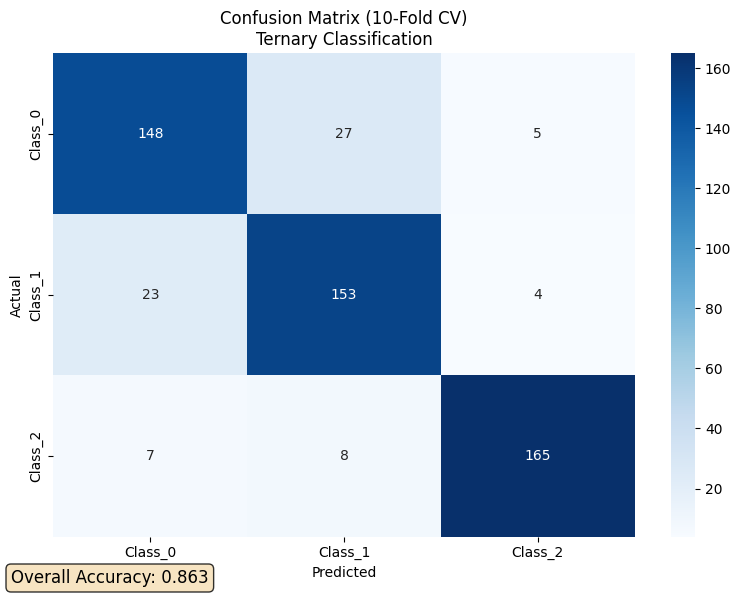

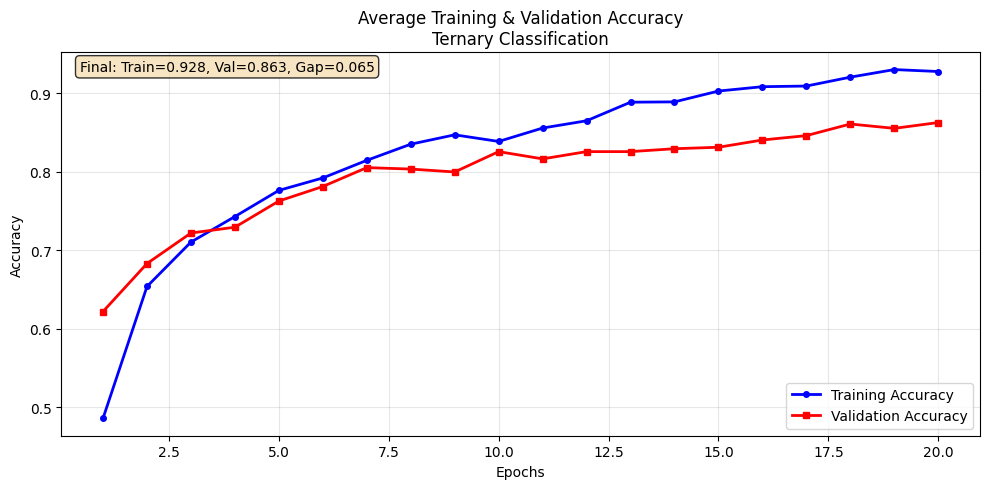

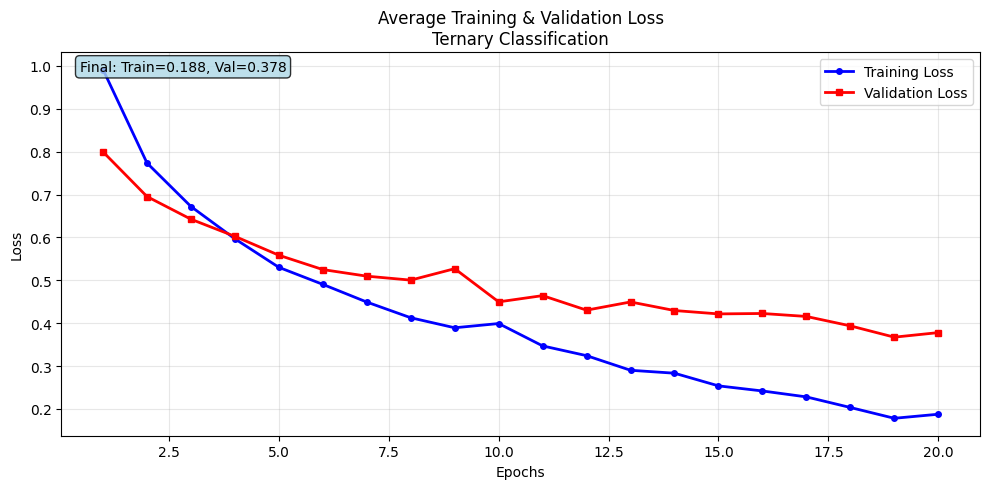

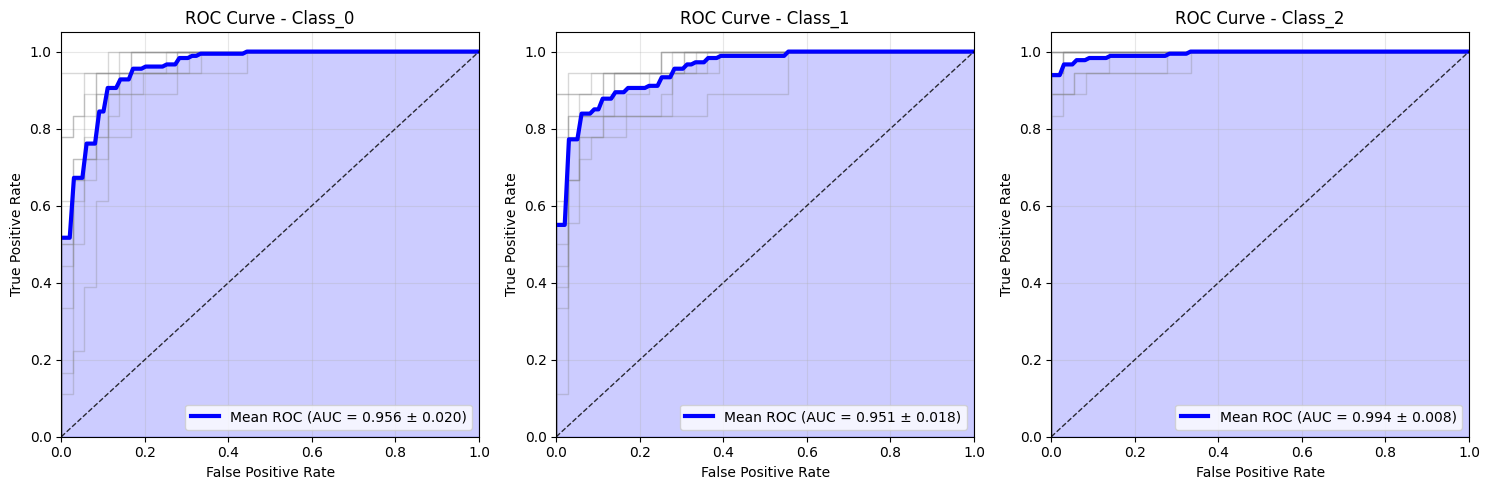

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6828\2000086083.py:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(f1_data, labels=class_names, patch_artist=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6828\2000086083.py:191: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(auc_data, labels=class_names, patch_artist=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6828\2000086083.py:202: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(overall_data, labels=['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'], patch_artist=True)


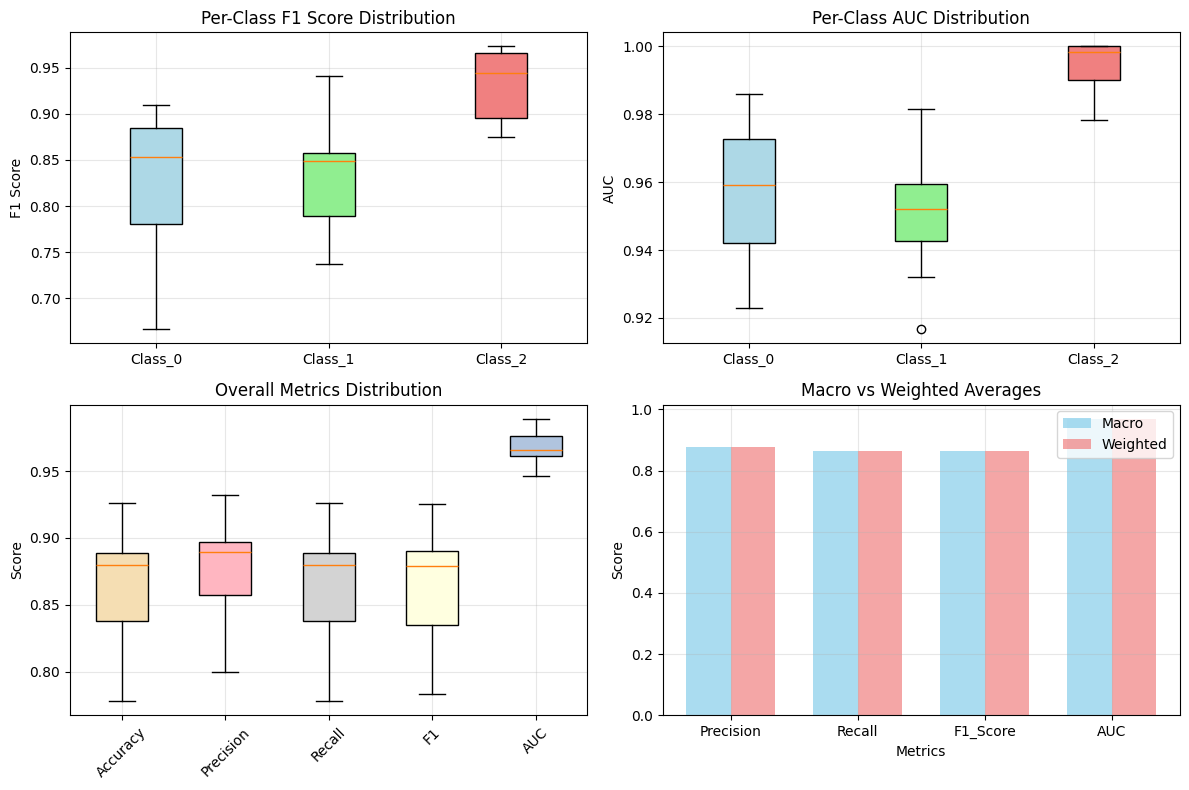


🎯 MODEL SELECTION ANALYSIS:
   Best Accuracy:  Fold 6.0 (0.9259)
   Best AUC:       Fold 2.0 (0.9892)
   Best F1-Score:  Fold 6.0 (0.9256)
   Consistent Models: 7 folds with accuracy > 0.839

📊 BEST MODELS BY CLASS:
   Class_0:
     Best F1:  Fold 6.0 (0.9091)
     Best AUC: Fold 2.0 (0.9861)
   Class_1:
     Best F1:  Fold 7.0 (0.9412)
     Best AUC: Fold 2.0 (0.9815)
   Class_2:
     Best F1:  Fold 6.0 (0.9730)
     Best AUC: Fold 2.0 (1.0000)

💾 Files saved:
   - cv_results/ternary_results.csv
   - cv_results/models/gru_ternary_fold_1.h5 to gru_ternary_fold_10.h5 (trained models)
   - cv_results/training_logs/fold_training_summary.csv (training summary)
   - cv_results/training_logs/epoch_by_epoch_history.csv (detailed epoch data)
   - cv_results/training_logs/training_statistics.csv (aggregated stats)
   - cv_results/training_logs/convergence_analysis.csv (convergence analysis)
   - cv_results/training_logs/class_balance_analysis.csv (class balance info)
   - cv_results/training_l

In [4]:
# Save all analysis to CSV files
df_training_stats = pd.DataFrame(training_stats_data)
df_training_stats.to_csv('cv_results/training_logs/training_statistics.csv', index=False)

df_convergence_analysis = pd.DataFrame(convergence_analysis_data)
df_convergence_analysis.to_csv('cv_results/training_logs/convergence_analysis.csv', index=False)

df_class_balance = pd.DataFrame(class_balance_data)
df_class_balance.to_csv('cv_results/training_logs/class_balance_analysis.csv', index=False)

print(f"\n📝 TRAINING LOGS SAVED:")
print(f"   - cv_results/training_logs/fold_training_summary.csv (summary per fold)")
print(f"   - cv_results/training_logs/epoch_by_epoch_history.csv (detailed epoch data)")
print(f"   - cv_results/training_logs/training_statistics.csv (aggregated stats)")
print(f"   - cv_results/training_logs/convergence_analysis.csv (convergence analysis)")
print(f"   - cv_results/training_logs/class_balance_analysis.csv (class balance info)")
print(f"   - cv_results/training_logs/fold_X_detailed_history.csv (individual fold histories)")

# Print summary
print(f"\n📊 TERNARY CLASSIFICATION RESULTS SUMMARY:")
print(f"   Accuracy:          {df_results['Val_Accuracy'].mean():.4f} ± {df_results['Val_Accuracy'].std():.4f}")
print(f"   Precision (Macro): {df_results['Precision_Macro'].mean():.4f} ± {df_results['Precision_Macro'].std():.4f}")
print(f"   Recall (Macro):    {df_results['Recall_Macro'].mean():.4f} ± {df_results['Recall_Macro'].std():.4f}")
print(f"   F1-Score (Macro):  {df_results['F1_Score_Macro'].mean():.4f} ± {df_results['F1_Score_Macro'].std():.4f}")
print(f"   AUC (Macro):       {df_results['AUC_Macro'].mean():.4f} ± {df_results['AUC_Macro'].std():.4f}")

print(f"\n📈 TRAINING SUMMARY:")
print(f"   Avg Epochs Completed: {df_training_logs['epochs_completed'].mean():.1f} ± {df_training_logs['epochs_completed'].std():.1f}")
print(f"   Avg Training Time:    {df_training_logs['training_time'].mean():.1f} ± {df_training_logs['training_time'].std():.1f} seconds")
print(f"   Early Stopped Folds:  {df_training_logs['early_stopped'].sum()}/10")
print(f"   Avg Overfitting Gap:  {df_training_logs['overfitting_gap'].mean():.4f} ± {df_training_logs['overfitting_gap'].std():.4f}")
print(f"   Best Val Acc Epoch:   {df_training_logs['best_val_accuracy_epoch'].mean():.1f} ± {df_training_logs['best_val_accuracy_epoch'].std():.1f}")

print(f"\n📊 PER-CLASS PERFORMANCE:")
for i in range(3):
    print(f"   {class_names[i]}:")
    print(f"     Precision: {df_results[f'Precision_Class_{i}'].mean():.4f} ± {df_results[f'Precision_Class_{i}'].std():.4f}")
    print(f"     Recall:    {df_results[f'Recall_Class_{i}'].mean():.4f} ± {df_results[f'Recall_Class_{i}'].std():.4f}")
    print(f"     F1-Score:  {df_results[f'F1_Class_{i}'].mean():.4f} ± {df_results[f'F1_Class_{i}'].std():.4f}")
    print(f"     AUC:       {df_results[f'AUC_Class_{i}'].mean():.4f} ± {df_results[f'AUC_Class_{i}'].std():.4f}")

# ==================== VISUALIZATIONS ====================

# 1. CONFUSION MATRIX
plt.figure(figsize=(8, 6))
sum_cm = np.sum(confusion_matrices, axis=0)
sns.heatmap(sum_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (10-Fold CV)\nTernary Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Add overall accuracy
total_samples = np.sum(sum_cm)
correct_predictions = np.trace(sum_cm)
overall_accuracy = correct_predictions / total_samples
plt.figtext(0.02, 0.02, f'Overall Accuracy: {overall_accuracy:.3f}', 
            fontsize=12, ha='left', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('cv_results/ternary_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. TRAINING & VALIDATION ACCURACY
plt.figure(figsize=(10, 5))

# Calculate average accuracy across folds
max_epochs = max(len(h['accuracy']) for h in all_histories)
avg_train_acc = []
avg_val_acc = []

for epoch in range(max_epochs):
    train_accs = [h['accuracy'][epoch] for h in all_histories if len(h['accuracy']) > epoch]
    val_accs = [h['val_accuracy'][epoch] for h in all_histories if len(h['val_accuracy']) > epoch]
    avg_train_acc.append(np.mean(train_accs))
    avg_val_acc.append(np.mean(val_accs))

epochs = range(1, len(avg_train_acc) + 1)
plt.plot(epochs, avg_train_acc, 'b-', label='Training Accuracy', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, avg_val_acc, 'r-', label='Validation Accuracy', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Average Training & Validation Accuracy\nTernary Classification')
plt.legend()
plt.grid(True, alpha=0.3)

# Add final accuracy values
final_train = avg_train_acc[-1]
final_val = avg_val_acc[-1]
plt.text(0.02, 0.98, f'Final: Train={final_train:.3f}, Val={final_val:.3f}, Gap={final_train-final_val:.3f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('cv_results/ternary_accuracy_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. TRAINING & VALIDATION LOSS
plt.figure(figsize=(10, 5))

# Calculate average loss across folds
avg_train_loss = []
avg_val_loss = []

for epoch in range(max_epochs):
    train_losses = [h['loss'][epoch] for h in all_histories if len(h['loss']) > epoch]
    val_losses = [h['val_loss'][epoch] for h in all_histories if len(h['val_loss']) > epoch]
    avg_train_loss.append(np.mean(train_losses))
    avg_val_loss.append(np.mean(val_losses))

plt.plot(epochs, avg_train_loss, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, avg_val_loss, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Average Training & Validation Loss\nTernary Classification')
plt.legend()
plt.grid(True, alpha=0.3)

# Add final loss values
final_train_loss = avg_train_loss[-1]
final_val_loss = avg_val_loss[-1]
plt.text(0.02, 0.98, f'Final: Train={final_train_loss:.3f}, Val={final_val_loss:.3f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('cv_results/ternary_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. ROC CURVES (One for each class)
plt.figure(figsize=(15, 5))

for class_idx in range(3):
    plt.subplot(1, 3, class_idx + 1)
    
    # Plot ROC for each fold (light lines)
    for fold_roc in all_roc_data:
        fpr = fold_roc[f'class_{class_idx}']['fpr']
        tpr = fold_roc[f'class_{class_idx}']['tpr']
        plt.plot(fpr, tpr, alpha=0.3, color='gray', linewidth=1)
    
    # Calculate and plot average ROC
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []
    
    for fold_roc in all_roc_data:
        fpr = fold_roc[f'class_{class_idx}']['fpr']
        tpr = fold_roc[f'class_{class_idx}']['tpr']
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        aucs.append(fold_roc[f'class_{class_idx}']['auc'])
    
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    
    # Fill area under curve
    plt.fill_between(mean_fpr, mean_tpr, alpha=0.2, color='blue')
    plt.plot(mean_fpr, mean_tpr, color='blue', linewidth=3,
             label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.8)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {class_names[class_idx]}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cv_results/ternary_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. PER-CLASS PERFORMANCE COMPARISON
plt.figure(figsize=(12, 8))

# Subplot 1: Per-class F1 Scores
plt.subplot(2, 2, 1)
f1_data = [df_results[f'F1_Class_{i}'].values for i in range(3)]
box_plot = plt.boxplot(f1_data, labels=class_names, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
plt.ylabel('F1 Score')
plt.title('Per-Class F1 Score Distribution')
plt.grid(True, alpha=0.3)

# Subplot 2: Per-class AUC
plt.subplot(2, 2, 2)
auc_data = [df_results[f'AUC_Class_{i}'].values for i in range(3)]
box_plot = plt.boxplot(auc_data, labels=class_names, patch_artist=True)
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
plt.ylabel('AUC')
plt.title('Per-Class AUC Distribution')
plt.grid(True, alpha=0.3)

# Subplot 3: Overall metrics comparison
plt.subplot(2, 2, 3)
overall_metrics = ['Val_Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Score_Macro', 'AUC_Macro']
overall_data = [df_results[col].values for col in overall_metrics]
box_plot = plt.boxplot(overall_data, labels=['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'], patch_artist=True)
metric_colors = ['wheat', 'lightpink', 'lightgray', 'lightyellow', 'lightsteelblue']
for patch, color in zip(box_plot['boxes'], metric_colors):
    patch.set_facecolor(color)
plt.ylabel('Score')
plt.title('Overall Metrics Distribution')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Subplot 4: Macro vs Weighted comparison
plt.subplot(2, 2, 4)
metrics = ['Precision', 'Recall', 'F1_Score', 'AUC']
macro_vals = [df_results[f'{m}_Macro'].mean() for m in metrics]
weighted_vals = [df_results[f'{m}_Weighted'].mean() for m in metrics]

x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, macro_vals, width, label='Macro', alpha=0.7, color='skyblue')
plt.bar(x + width/2, weighted_vals, width, label='Weighted', alpha=0.7, color='lightcoral')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Macro vs Weighted Averages')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cv_results/ternary_performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== MODEL SELECTION ====================

print(f"\n🎯 MODEL SELECTION ANALYSIS:")

# Best model by different criteria
best_acc_idx = df_results['Val_Accuracy'].idxmax()
best_auc_idx = df_results['AUC_Macro'].idxmax()
best_f1_idx = df_results['F1_Score_Macro'].idxmax()

print(f"   Best Accuracy:  Fold {df_results.iloc[best_acc_idx]['Fold']} ({df_results.iloc[best_acc_idx]['Val_Accuracy']:.4f})")
print(f"   Best AUC:       Fold {df_results.iloc[best_auc_idx]['Fold']} ({df_results.iloc[best_auc_idx]['AUC_Macro']:.4f})")
print(f"   Best F1-Score:  Fold {df_results.iloc[best_f1_idx]['Fold']} ({df_results.iloc[best_f1_idx]['F1_Score_Macro']:.4f})")

# Most consistent models
acc_mean = df_results['Val_Accuracy'].mean()
acc_std = df_results['Val_Accuracy'].std()
consistent_models = df_results[df_results['Val_Accuracy'] > (acc_mean - acc_std/2)]
print(f"   Consistent Models: {len(consistent_models)} folds with accuracy > {acc_mean - acc_std/2:.3f}")

# Class-specific best models
print(f"\n📊 BEST MODELS BY CLASS:")
for i in range(3):
    best_class_f1_idx = df_results[f'F1_Class_{i}'].idxmax()
    best_class_auc_idx = df_results[f'AUC_Class_{i}'].idxmax()
    print(f"   {class_names[i]}:")
    print(f"     Best F1:  Fold {df_results.iloc[best_class_f1_idx]['Fold']} ({df_results.iloc[best_class_f1_idx][f'F1_Class_{i}']:.4f})")
    print(f"     Best AUC: Fold {df_results.iloc[best_class_auc_idx]['Fold']} ({df_results.iloc[best_class_auc_idx][f'AUC_Class_{i}']:.4f})")

print(f"\n💾 Files saved:")
print(f"   - cv_results/ternary_results.csv")
print(f"   - cv_results/models/gru_ternary_fold_1.h5 to gru_ternary_fold_10.h5 (trained models)")
print(f"   - cv_results/training_logs/fold_training_summary.csv (training summary)")
print(f"   - cv_results/training_logs/epoch_by_epoch_history.csv (detailed epoch data)")
print(f"   - cv_results/training_logs/training_statistics.csv (aggregated stats)")
print(f"   - cv_results/training_logs/convergence_analysis.csv (convergence analysis)")
print(f"   - cv_results/training_logs/class_balance_analysis.csv (class balance info)")
print(f"   - cv_results/training_logs/fold_X_detailed_history.csv (individual histories)")
print(f"   - cv_results/ternary_confusion_matrix.png")
print(f"   - cv_results/ternary_accuracy_curves.png")
print(f"   - cv_results/ternary_loss_curves.png")
print(f"   - cv_results/ternary_roc_curves.png")
print(f"   - cv_results/ternary_performance_analysis.png")

print(f"\n🔍 TRAINING LOG ANALYSIS EXAMPLES:")
print(f"   # Load epoch-by-epoch data")
print(f"   df_epochs = pd.read_csv('cv_results/training_logs/epoch_by_epoch_history.csv')")
print(f"   # Filter ternary classification data")
print(f"   ternary_epochs = df_epochs[df_epochs['classification_type'] == 'ternary']")
print(f"   # Analyze convergence for specific fold")
print(f"   fold_1_data = ternary_epochs[ternary_epochs['fold'] == 1]")
print(f"   # Load training summary for analysis")
print(f"   df_summary = pd.read_csv('cv_results/training_logs/fold_training_summary.csv')")
print(f"   # Load convergence analysis")
print(f"   df_convergence = pd.read_csv('cv_results/training_logs/convergence_analysis.csv')")
print(f"   fastest_fold = df_convergence[df_convergence['analysis_type'] == 'fastest_convergence']['fold'].iloc[0]")

print(f"\n🔍 PER-CLASS ANALYSIS EXAMPLES:")
print(f"   # Load fold training summary for per-class metrics")
print(f"   df_summary = pd.read_csv('cv_results/training_logs/fold_training_summary.csv')")
print(f"   # Analyze per-class performance across folds")
print(f"   class_0_f1 = df_summary['f1_class_0'].mean()")
print(f"   class_1_f1 = df_summary['f1_class_1'].mean()")
print(f"   class_2_f1 = df_summary['f1_class_2'].mean()")
print(f"   # Load class balance analysis")
print(f"   df_balance = pd.read_csv('cv_results/training_logs/class_balance_analysis.csv')")
print(f"   print(df_balance)")

print(f"\n🔄 Model Loading Examples:")
print(f"   from tensorflow.keras.models import load_model")
print(f"   # Load best overall model")
print(f"   best_model = load_model('cv_results/models/gru_ternary_fold_{df_results.iloc[best_acc_idx]['Fold']:.0f}.h5')")
print(f"   # Load best model for specific class")
print(f"   best_class0_model = load_model('cv_results/models/gru_ternary_fold_{df_results.iloc[best_class_f1_idx]['Fold']:.0f}.h5')")
print(f"   # Prediction for ternary classification")
print(f"   predictions = best_model.predict(new_data)")
print(f"   predicted_classes = np.argmax(predictions, axis=1)")
print(f"   # Get prediction probabilities for each class")
print(f"   class_probabilities = predictions  # Shape: (n_samples, 3)")

print(f"\n🎯 ENSEMBLE PREDICTION EXAMPLE:")
print(f"   # Load all models for ensemble")
print(f"   models = []")
print(f"   for fold in range(1, 11):")
print(f"       model = load_model(f'cv_results/models/gru_ternary_fold_{{fold}}.h5')")
print(f"       models.append(model)")
print(f"   # Ensemble prediction")
print(f"   ensemble_pred = np.mean([model.predict(new_data) for model in models], axis=0)")
print(f"   ensemble_classes = np.argmax(ensemble_pred, axis=1)")

print(f"\n🔍 CLASS IMBALANCE ANALYSIS:")
df_balance = pd.DataFrame(class_balance_data)
total_samples = df_balance['avg_samples'].sum()
for i, row in df_balance.iterrows():
    class_proportion = row['avg_samples'] / total_samples
    print(f"   {row['class_name']} proportion: {class_proportion:.3f} ({row['avg_samples']:.1f} ± {row['std_samples']:.1f} samples)")

print(f"\n✅ Ternary classification cross-validation completed!")
print("=" * 60)